<a href="https://colab.research.google.com/github/EdwinZhanCN/Projects-in-ML-and-AI/blob/main/homework6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1

## Environment
In this task, I chose the `FrozenLake-v1` environment from the `gymnasium` library.
- State Space: A discrete space of 16 states (0 to 15), representing the 4 by 4 grid.
- Action Space: 4 actions: Left(0), Down(1), Right(2), Up(3).
- Reward Structure: Reaching the Goal gets +1.0, falling into a Hole yields 0.0, and walking on a Frozen tile yields 0.0.
- Discount Factor: Set to 0.99.

This environment satisfies the Markov Property, the probability of moving to some next state and receiving a specific reward depends on the current state and the action, independent of the past.

In [10]:
import numpy as np
import gymnasium as gym

# Implementation of Value Iteration
def value_iteration(env, gamma=0.99, theta=1e-8):
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    V = np.zeros(n_states)
    policy = np.zeros(n_states, dtype=int)

    # (probability, next_state, reward, terminated)
    P = env.unwrapped.P

    while True:
        delta = 0
        for s in range(n_states):
            v_old = V[s]
            action_values = np.zeros(n_actions)

            for a in range(n_actions):
                for prob, next_state, reward, terminated in P[s][a]:
                    # If terminated, set 0
                    action_values[a] += prob * (reward + gamma * V[next_state] * (not terminated))

            V[s] = np.max(action_values)
            policy[s] = np.argmax(action_values)
            delta = max(delta, abs(v_old - V[s]))

        if delta < theta:
            break

    return V, policy

def print_policy(policy, env):
    action_mapping = {0: '←', 1: '↓', 2: '→', 3: '↑'}
    desc = env.unwrapped.desc.tolist()
    grid_size = int(np.sqrt(env.observation_space.n))

    print("-" * 25)
    for row in range(grid_size):
        row_str = ""
        for col in range(grid_size):
            state = row * grid_size + col
            cell_type = desc[row][col].decode('utf-8')
            if cell_type == 'H':
                row_str += " H |"
            elif cell_type == 'G':
                row_str += " G |"
            else:
                row_str += f" {action_mapping[policy[state]]} |"
        print(row_str)
        print("-" * 25)

def print_value(V, env):
    grid_size = int(np.sqrt(env.observation_space.n))
    print("-" * 35)
    for row in range(grid_size):
        row_values = [f"{V[row * grid_size + col]:.4f}" for col in range(grid_size)]
        print(" | ".join(row_values))
        print("-" * 35)

In [11]:
env_base = gym.make('FrozenLake-v1', map_name="4x4", is_slippery=True)

# Run Value Iteration
V_base, policy_base = value_iteration(env_base, gamma=0.99)

print("=== Value Function ===")
print_value(V_base, env_base)

print("\n=== Policy ===")
print_policy(policy_base, env_base)

=== Value Function ===
-----------------------------------
0.5420 | 0.4988 | 0.4707 | 0.4569
-----------------------------------
0.5585 | 0.0000 | 0.3583 | 0.0000
-----------------------------------
0.5918 | 0.6431 | 0.6152 | 0.0000
-----------------------------------
0.0000 | 0.7417 | 0.8628 | 0.0000
-----------------------------------

=== Policy ===
-------------------------
 ← | ↑ | ↑ | ↑ |
-------------------------
 ← | H | ← | H |
-------------------------
 ↑ | ↓ | ← | H |
-------------------------
 H | → | ↓ | G |
-------------------------


## Tuning Experiment
I will change the environment where:
1. Falling into a Hole yields harsh penalty of -1.0.
2. Introduce a small living penalty of -0.05.

We will observe how this shifts the agent's risk tolerance.

In [12]:
env_exp = gym.make('FrozenLake-v1', map_name="4x4", is_slippery=True)
P_exp = env_exp.unwrapped.P

# New reward structure
for s in P_exp:
    for a in P_exp[s]:
        new_transitions = []
        for prob, next_state, reward, terminated in P_exp[s][a]:
            if terminated and reward == 0:
                reward = -1.0  # Hole penalty
            elif not terminated:
                reward = -0.05 # Living penalty

            new_transitions.append((prob, next_state, reward, terminated))
        P_exp[s][a] = new_transitions

V_exp, policy_exp = value_iteration(env_exp, gamma=0.99)

print("=== Value Function ===")
print_value(V_exp, env_exp)

print("\n=== Policy ===")
print_policy(policy_exp, env_exp)

=== Value Function ===
-----------------------------------
-1.0246 | -1.0231 | -0.9661 | -1.0231
-----------------------------------
-0.9057 | -1.0000 | -0.7869 | -1.0000
-----------------------------------
-0.7277 | -0.4203 | -0.3137 | -1.0000
-----------------------------------
-1.0000 | -0.0807 | 0.4080 | -1.0000
-----------------------------------

=== Policy ===
-------------------------
 → | → | ← | ← |
-------------------------
 ↓ | H | ↓ | H |
-------------------------
 ↑ | ↓ | ← | H |
-------------------------
 H | → | ↓ | G |
-------------------------


## Discussion

Base Policy:

Under the standard reward structure the agent's primary goal is maximizing the probability of reaching the goal without penalization for taking long. Because the ice is slippery, the agent learns to point its actions toward walls when nearing holes.
    
Experimental Policy:

When we introduced the living penalty, the agent abandoned its safety strategy (at top row `→ | → | ← | ← |`). repeatedly bouncing against a wall is no longer a solution. It is forced to moving aggressively toward the goal even if it increases the probability of slipping into holes.

## Task 2

### CLIP for prompt sensitivity

Primary source 1: Radford, A., et al. (2021). "Learning Transferable Visual Models From Natural Language Supervision."

Primary source 2: Zhou, et al.(2021) "Learning to Prompt for Vision-Language Models."

Model Technical Source:
[Huggingface Transformers](https://huggingface.co/docs/transformers/model_doc/clip)

#### Problem Solved

Traditional computer vision model like ResNet rely on many fixed-category datasets like ImageNet, which limits their ability to generalize.

#### Core Idea

CLIP proposed a method to use contrastive learning and compute the symmetric loss in dot product of image and text emebedding. It learns massive amount of image-text pairs from the internet. Which allows model gains impressive zero-shot classification capabilities.

#### Architecture & Training Objective
CLIP consists of two encoders, an Image Encoder (Vision Transformer/ResNet) and a Text Encoder (Transformer). During the training, the model learns by symmetric loss between batch of images and texts, the goal is to maximize the cosine similarity between image embedding and text embedding, and minimize the similarty between mismatched pairs.

### Experiment

This small experiment aims to verify how CLIP's image zero-shot classification confidence changes when we use different text prompts with similar meaning.

We will use the huggingface transformer library and the OpenAI/CLIP-ViT-B-16 model for evaluation.



In [13]:
%pip install transformers torch matplotlib pillow requests

In [14]:
import torch
import requests
from PIL import Image
import matplotlib.pyplot as plt
from transformers import CLIPProcessor, CLIPModel


In [15]:
model_id = "openai/clip-vit-base-patch16"
model = CLIPModel.from_pretrained(model_id)
processor = CLIPProcessor.from_pretrained(model_id)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


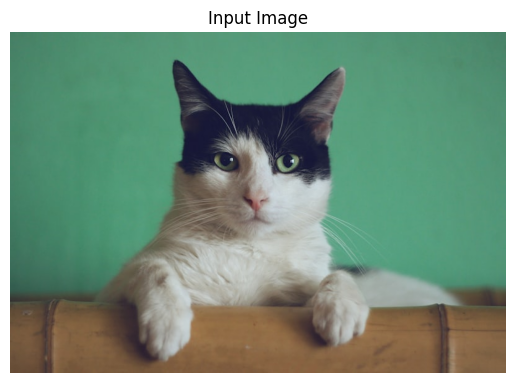

In [16]:
# We will use a cat image online as the test case
url = "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?ixlib=rb-4.0.3&auto=format&fit=crop&w=800&q=80"
image = Image.open(requests.get(url, stream=True).raw)

# Given different prompt to describe an image with cat
prompts = [
    "A cat",
    "A photo of cat",
    "A high-quality photo of cat",
    "A cute cat",
    "A cropped picture of a feline",
    "A dog"
]

plt.imshow(image)
plt.axis('off')
plt.title("Input Image")
plt.show()

In [17]:
inputs = processor(text=prompts, images=image, return_tensors="pt", padding=True)

with torch.no_grad():
  outputs = model(**inputs)

logits_per_image = outputs.logits_per_image
probs = logits_per_image.softmax(dim=1).cpu().numpy()[0]

for prompt, prob in zip(prompts, probs):
  print(f"{prompt}: {prob:.4f}")

A cat: 0.0833
A photo of cat: 0.4979
A high-quality photo of cat: 0.1263
A cute cat: 0.1538
A cropped picture of a feline: 0.1379
A dog: 0.0008


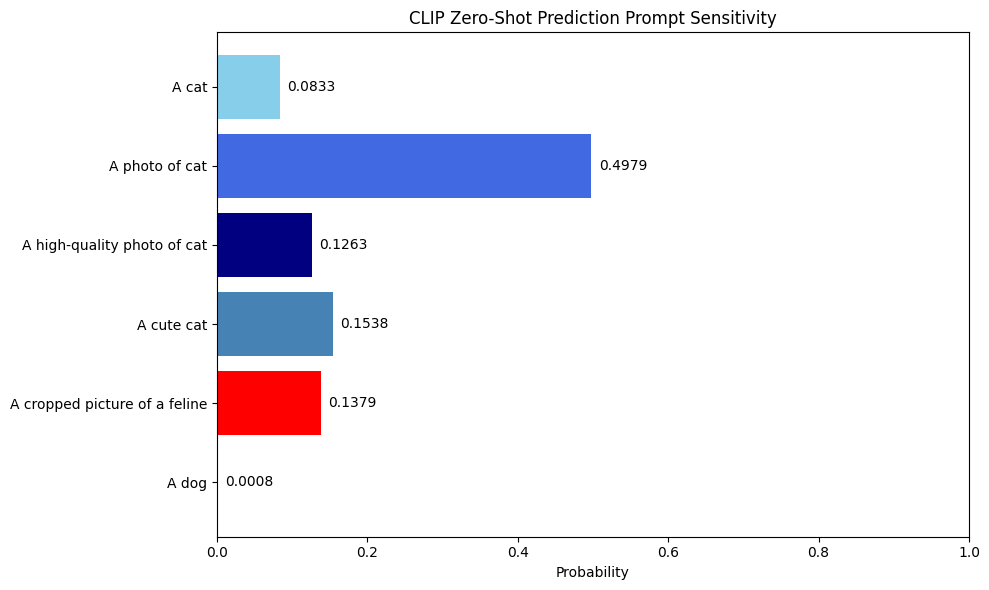

In [18]:
# Drawing a figure to represent the sensitivity of prompt
plt.figure(figsize=(10, 6))
bars = plt.barh(prompts, probs, color=['skyblue', 'royalblue', 'navy', 'steelblue', 'red'])
plt.xlabel('Probability')
plt.title('CLIP Zero-Shot Prediction Prompt Sensitivity')
plt.xlim(0, 1)

for bar in bars:
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.4f}', va='center')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Discussion

The figure shown above demonstrates significant ambiguity regarding the prompts used in the zero-shot classification experiment.

The most common and highly recommended prompt format, "A photo of a cat," yields the highest confidence score. In contrast, vague or non-optimized prompts result in significantly lower confidence levels compared to the standard "A photo of a cat" template.

### Limitations

Prompt engineering in zero-shot classification is notably fragile; the model's performance and confidence are highly dependent on the specific design of the prompts. Even minor grammatical changes or the addition of adjectives can drastically alter the results.

Furthermore, despite the power of the Transformer architecture, the CLIP model itself still lacks a sophisticated understanding of complex spatial relationships, like understanding the term of "high-quality", "cropped" or "cute".

### Improvements

To better leverage prompt engineering and address the issues observed in this experiment, we can align our approach with current industry standards by using "prompt ensembling." Instead of relying on a single string, we can pre-build a variety of templates, such as "A photo of a {}," "A drawing of a {}," and "A high-quality image of a {}."

By averaging the resulting text embeddings from these multiple prompts, we can compute a more robust similarity score against the image features, given more stable and accurate classification.

